#Poission Distribution






In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('hour.csv')
df.head(50)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [3]:
df.shape

(17379, 17)

#### We first estimate the Poisson rate λ from the dataset, then generate artificial Poisson samples using that λ.

season = 3

workingday = 1

hr = 4

#### Summer season, working day, 4 AM bike rentals

In [4]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("hour.csv")

# Select a smaller subset that is more suitable for Poisson
subset = df[
    (df["season"] == 3) &
    (df["workingday"] == 1) &
    (df["hr"] == 4)
]

# Estimate lambda from the real data
# finds the average number of bike rentals for that selected condition.
lambda_value = subset["cnt"].mean()

print("Estimated lambda:", lambda_value)

# Generate Poisson samples
np.random.seed(42)
poisson_samples = np.random.poisson(lam=lambda_value, size=1000)

print("First 20 generated Poisson samples:")
print(poisson_samples[:20])

Estimated lambda: 7.015267175572519
First 20 generated Poisson samples:
[ 6  7  6  7  7  4 12  2  7  5  7  6 10  3  6 12  5  6  9  6]


# λ=7.02
# On average, around 7 bikes are rented at 4 AM during working days in season 3.

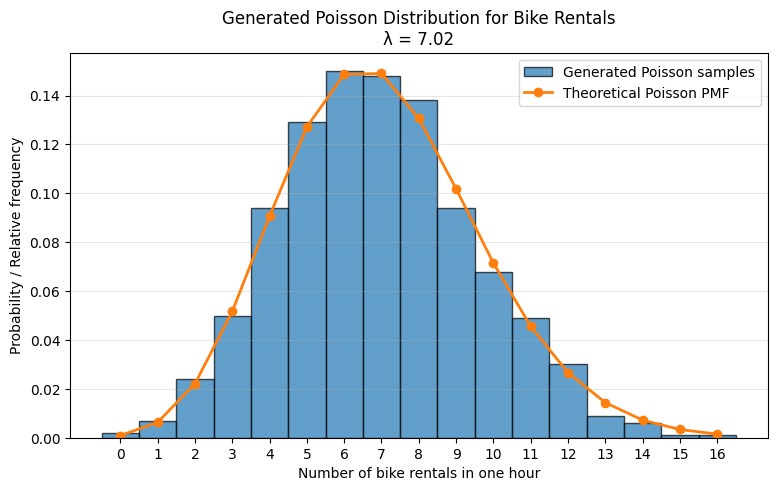

Estimated lambda: 7.02
Mean of generated samples: 6.92
Variance of generated samples: 6.69


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# Load dataset
df = pd.read_csv("hour.csv")

# Select subset
subset = df[
    (df["season"] == 3) &
    (df["workingday"] == 1) &
    (df["hr"] == 4)
]

# Estimate lambda
lambda_value = subset["cnt"].mean()

# Generate Poisson samples
np.random.seed(42)
poisson_samples = np.random.poisson(lam=lambda_value, size=1000)

# Theoretical Poisson PMF
x_values = np.arange(0, max(poisson_samples) + 1)

pmf_values = [
    (lambda_value ** k) * math.exp(-lambda_value) / math.factorial(k)
    for k in x_values
]

# Plot
plt.figure(figsize=(9, 5))

plt.hist(
    poisson_samples,
    bins=np.arange(min(poisson_samples), max(poisson_samples) + 2) - 0.5,
    density=True,
    edgecolor="black",
    alpha=0.7,
    label="Generated Poisson samples"
)

plt.plot(
    x_values,
    pmf_values,
    marker="o",
    linewidth=2,
    label="Theoretical Poisson PMF"
)

plt.title(f"Generated Poisson Distribution for Bike Rentals\nλ = {lambda_value:.2f}")
plt.xlabel("Number of bike rentals in one hour")
plt.ylabel("Probability / Relative frequency")
plt.xticks(x_values)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

print(f"Estimated lambda: {lambda_value:.2f}")
print(f"Mean of generated samples: {poisson_samples.mean():.2f}")
print(f"Variance of generated samples: {poisson_samples.var(ddof=1):.2f}")

Estimated lambda: 7.0153
    k (bike rentals)  PMF: P(X = k)  CDF: P(X ≤ k)
0                  0       0.000898       0.000898
1                  1       0.006300       0.007198
2                  2       0.022099       0.029297
3                  3       0.051676       0.080973
4                  4       0.090630       0.171603
5                  5       0.127159       0.298763
6                  6       0.148676       0.447439
7                  7       0.149000       0.596439
8                  8       0.130660       0.727099
9                  9       0.101846       0.828944
10                10       0.071448       0.900392
11                11       0.045566       0.945958
12                12       0.026638       0.972596
13                13       0.014375       0.986971
14                14       0.007203       0.994174
15                15       0.003369       0.997542
16                16       0.001477       0.999019
17                17       0.000610       0.999629
18    

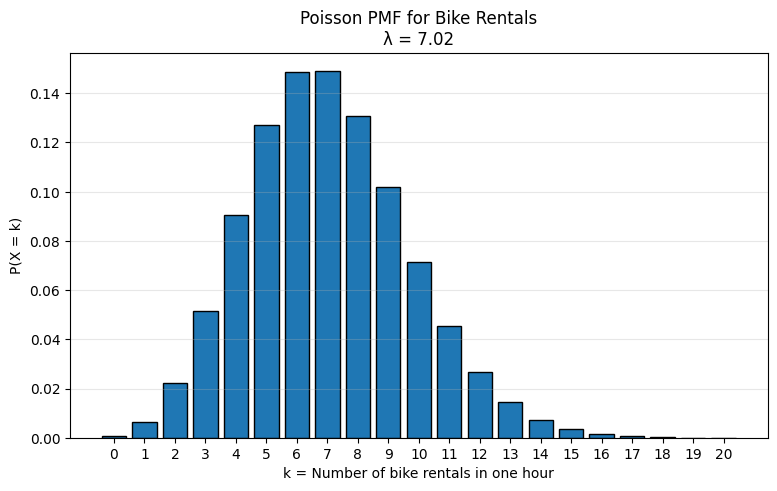

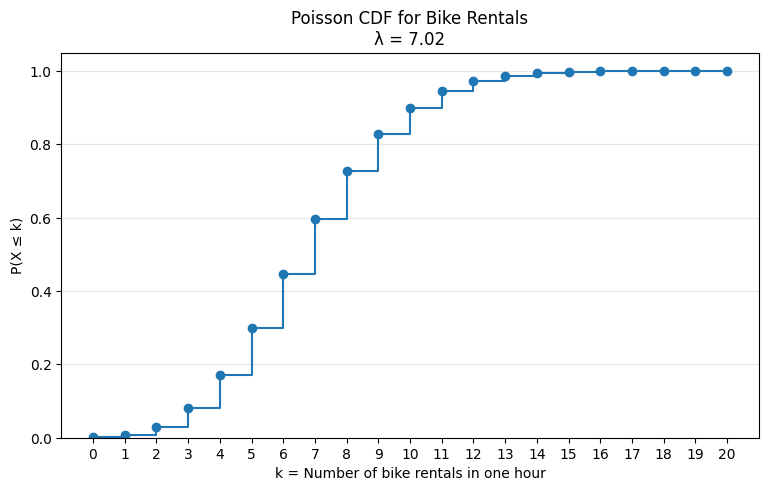

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# Load dataset
df = pd.read_csv("hour.csv")

# Select the same Poisson-friendly subset
subset = df[
    (df["season"] == 3) &
    (df["workingday"] == 1) &
    (df["hr"] == 4)
]

# Estimate lambda from the real data
lambda_value = subset["cnt"].mean()

# Possible bike rental counts
max_k = 20
k_values = np.arange(0, max_k + 1)

# Calculate Poisson PMF
pmf_values = np.array([
    (lambda_value ** k) * math.exp(-lambda_value) / math.factorial(k)
    for k in k_values
])

# Calculate CDF by cumulatively adding PMF values
cdf_values = np.cumsum(pmf_values)

# Create table
pmf_cdf_table = pd.DataFrame({
    "k (bike rentals)": k_values,
    "PMF: P(X = k)": pmf_values,
    "CDF: P(X ≤ k)": cdf_values
})

print(f"Estimated lambda: {lambda_value:.4f}")
print(pmf_cdf_table)

# Plot PMF
plt.figure(figsize=(9, 5))
plt.bar(k_values, pmf_values, edgecolor="black")
plt.title(f"Poisson PMF for Bike Rentals\nλ = {lambda_value:.2f}")
plt.xlabel("k = Number of bike rentals in one hour")
plt.ylabel("P(X = k)")
plt.xticks(k_values)
plt.grid(axis="y", alpha=0.3)
plt.show()

# Plot CDF
plt.figure(figsize=(9, 5))
plt.step(k_values, cdf_values, where="post", marker="o")
plt.title(f"Poisson CDF for Bike Rentals\nλ = {lambda_value:.2f}")
plt.xlabel("k = Number of bike rentals in one hour")
plt.ylabel("P(X ≤ k)")
plt.xticks(k_values)
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.show()

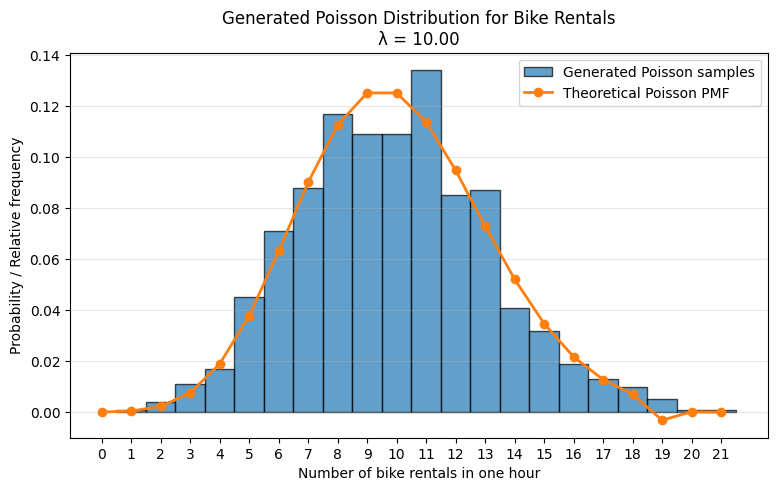

Estimated lambda: 10.00
Mean of generated samples: 9.90
Variance of generated samples: 10.42


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# Load dataset
df = pd.read_csv("hour.csv")

# Select subset
subset = df[
    (df["season"] == 3) &
    (df["workingday"] == 1) &
    (df["hr"] == 4)
]

# Estimate lambda
lambda_value = 10

# Generate Poisson samples
np.random.seed(42)
poisson_samples = np.random.poisson(lam=lambda_value, size=1000)

# Theoretical Poisson PMF
x_values = np.arange(0, max(poisson_samples) + 1)

pmf_values = [
    (lambda_value ** k) * math.exp(-lambda_value) / math.factorial(k)
    for k in x_values
]

# Plot
plt.figure(figsize=(9, 5))

plt.hist(
    poisson_samples,
    bins=np.arange(min(poisson_samples), max(poisson_samples) + 2) - 0.5,
    density=True,
    edgecolor="black",
    alpha=0.7,
    label="Generated Poisson samples"
)

plt.plot(
    x_values,
    pmf_values,
    marker="o",
    linewidth=2,
    label="Theoretical Poisson PMF"
)

plt.title(f"Generated Poisson Distribution for Bike Rentals\nλ = {lambda_value:.2f}")
plt.xlabel("Number of bike rentals in one hour")
plt.ylabel("Probability / Relative frequency")
plt.xticks(x_values)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

print(f"Estimated lambda: {lambda_value:.2f}")
print(f"Mean of generated samples: {poisson_samples.mean():.2f}")
print(f"Variance of generated samples: {poisson_samples.var(ddof=1):.2f}")

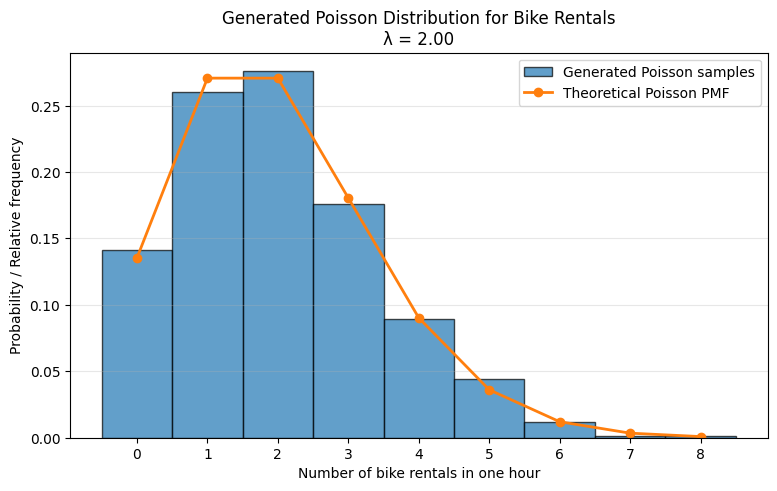

Estimated lambda: 2.00
Mean of generated samples: 2.00
Variance of generated samples: 2.01


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# Load dataset
df = pd.read_csv("hour.csv")

# Select subset
subset = df[
    (df["season"] == 3) &
    (df["workingday"] == 1) &
    (df["hr"] == 4)
]

# Estimate lambda
lambda_value = 2
# Generate Poisson samples
np.random.seed(42)
poisson_samples = np.random.poisson(lam=lambda_value, size=1000)

# Theoretical Poisson PMF
x_values = np.arange(0, max(poisson_samples) + 1)

pmf_values = [
    (lambda_value ** k) * math.exp(-lambda_value) / math.factorial(k)
    for k in x_values
]

# Plot
plt.figure(figsize=(9, 5))

plt.hist(
    poisson_samples,
    bins=np.arange(min(poisson_samples), max(poisson_samples) + 2) - 0.5,
    density=True,
    edgecolor="black",
    alpha=0.7,
    label="Generated Poisson samples"
)

plt.plot(
    x_values,
    pmf_values,
    marker="o",
    linewidth=2,
    label="Theoretical Poisson PMF"
)

plt.title(f"Generated Poisson Distribution for Bike Rentals\nλ = {lambda_value:.2f}")
plt.xlabel("Number of bike rentals in one hour")
plt.ylabel("Probability / Relative frequency")
plt.xticks(x_values)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

print(f"Estimated lambda: {lambda_value:.2f}")
print(f"Mean of generated samples: {poisson_samples.mean():.2f}")
print(f"Variance of generated samples: {poisson_samples.var(ddof=1):.2f}")

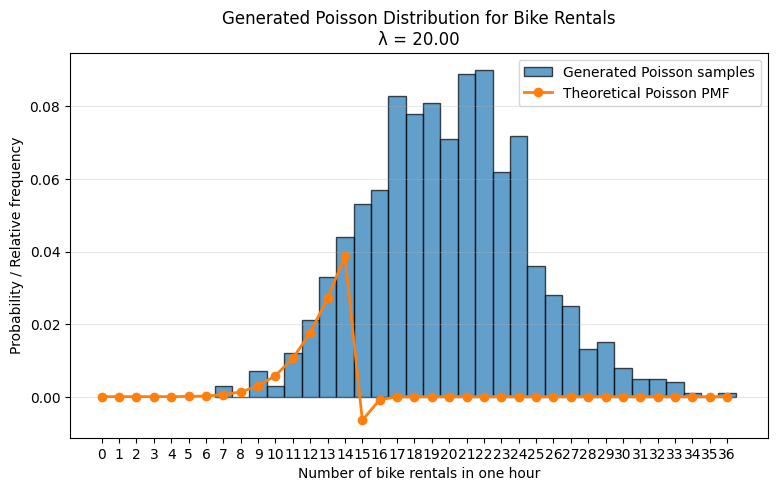

Estimated lambda: 20.00
Mean of generated samples: 19.89
Variance of generated samples: 21.15


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# Load dataset
df = pd.read_csv("hour.csv")

# Select subset
subset = df[
    (df["season"] == 3) &
    (df["workingday"] == 1) &
    (df["hr"] == 4)
]

# Estimate lambda
lambda_value = 20

# Generate Poisson samples
np.random.seed(42)
poisson_samples = np.random.poisson(lam=lambda_value, size=1000)

# Theoretical Poisson PMF
x_values = np.arange(0, max(poisson_samples) + 1)

pmf_values = [
    (lambda_value ** k) * math.exp(-lambda_value) / math.factorial(k)
    for k in x_values
]

# Plot
plt.figure(figsize=(9, 5))

plt.hist(
    poisson_samples,
    bins=np.arange(min(poisson_samples), max(poisson_samples) + 2) - 0.5,
    density=True,
    edgecolor="black",
    alpha=0.7,
    label="Generated Poisson samples"
)

plt.plot(
    x_values,
    pmf_values,
    marker="o",
    linewidth=2,
    label="Theoretical Poisson PMF"
)

plt.title(f"Generated Poisson Distribution for Bike Rentals\nλ = {lambda_value:.2f}")
plt.xlabel("Number of bike rentals in one hour")
plt.ylabel("Probability / Relative frequency")
plt.xticks(x_values)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

print(f"Estimated lambda: {lambda_value:.2f}")
print(f"Mean of generated samples: {poisson_samples.mean():.2f}")
print(f"Variance of generated samples: {poisson_samples.var(ddof=1):.2f}")